# LocusZoom-style plot for a lead GWAS SNP (with LD coloring)

This script creates a locus plot centered on a **lead SNP** and colors nearby variants by **LD (R²)** with the lead SNP using the **LDlink** API.

## What you need to do

1. **Install R packages** (once):
   - `data.table`, `ggplot2`, `ggrepel`, `LDlinkR`, and optionally `Cairo` if you want high-quality PDF output.

2. **Get an LDlink token**
   - Request your personal token from LDlink and replace `ld_token` with your own.
   - The script queries LD proxies with: `pop = "EUR"` and `genome_build = "grch38"`.

3. **Prepare the GWAS input file**
   - Download the GWAS summary statistics file from our `figshare`.

4. **Set the lead SNP**
   - Edit `lead_snp <- "rs2985994"` to the rsID you want to center on.

Loading required package: sysfonts

Loading required package: showtextdb


LDlink server is working...




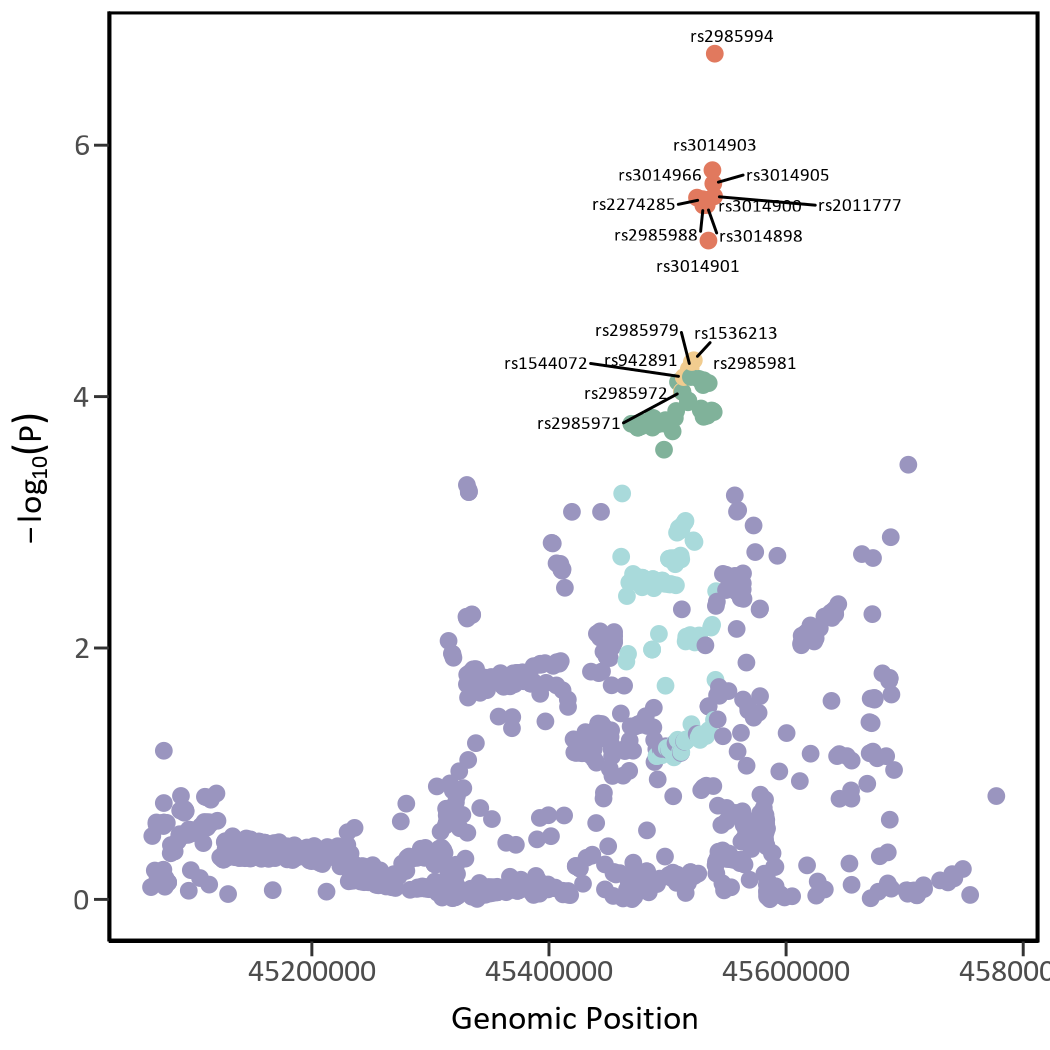

In [ ]:
# ================================================================
# 0. Dependencies — install packages first if missing
# ================================================================
library(data.table)
library(ggplot2)
library(ggrepel)
library(LDlinkR)
library(showtext)

# In notebooks, force PNG rendering to avoid PDF/PostScript font issues
options(repr.plot.mime = "image/png")
options(repr.plot.res  = 150)

# Register Calibri from local TTF files
font_dir <- "/home/wangyubo/code/font"  # folder containing .ttf
font_add(
  family  = "Calibri",
  regular = file.path(font_dir, "CALIBRI.TTF"),
  bold    = file.path(font_dir, "CALIBRI.TTF"),
  italic  = file.path(font_dir, "CALIBRI.TTF")
)

# IMPORTANT: enable showtext so TTF fonts work on all devices
showtext_auto(enable = TRUE)

# ================================================================
# 1. Parameters
# ================================================================
lead_snp  <- "rs2985994"  # lead SNP
gwas_path <- "../../results/reproducibility/gwas_resources/GCST90027164_buildGRCh38.tsv"
ld_token  <- "Your_LDlink_token"  # your LDlink token
out_pdf   <- "manhattan_LocusZoom.pdf"

# ================================================================
# 2. Load GWAS summary statistics
# ================================================================
gwas <- fread(gwas_path)
gwas[, p_value := as.numeric(gsub(",", ".", p_value))]  # handle comma decimals if present
gwas <- gwas[!is.na(p_value)]
gwas[, logP := -log10(p_value)]
setnames(gwas, "chromosome", "chr")
gwas[, chr := as.character(chr)]  # keep chr as character for consistent joins

# ================================================================
# 3. Query LD proxies (EUR, GRCh38)
# ================================================================
ld_raw <- LDproxy(
  snp          = lead_snp,
  pop          = "EUR",
  r2d          = "r2",
  genome_build = "grch38",
  token        = ld_token,
  file         = FALSE
)

setDT(ld_raw)
ld_raw[, R2 := as.numeric(R2)]

# 3.1 Parse coordinates -> chr / pos (LDlink schema may change)
coord_col <- if ("Coord" %in% names(ld_raw)) "Coord" else
             if ("Coordinate" %in% names(ld_raw)) "Coordinate" else
             stop("LDproxy output changed: cannot find 'Coord' / 'Coordinate' column.")

ld_raw[, c("chr", "pos") := tstrsplit(get(coord_col), ":", fixed = TRUE)]
ld_raw[, chr := sub("^chr", "", chr)]
ld_raw[, pos := as.integer(pos)]

# 3.2 Keep the lead SNP row (if present) and proxies with valid R2
ld <- ld_raw[RS_Number == lead_snp | (!is.na(R2) & R2 >= 0)]

# ================================================================
# 4. If the lead SNP row is missing, add a placeholder row
# ================================================================
if (!any(ld$RS_Number == lead_snp)) {
  lead_chr_proxy <- ld$chr[1]
  lead_pos_proxy <- ld$pos[1]

  new_row <- as.list(rep(NA, ncol(ld)))
  names(new_row) <- names(ld)
  new_row[c("RS_Number", "chr", "pos", "R2")] <-
    list(lead_snp, lead_chr_proxy, lead_pos_proxy, NA_real_)

  ld <- rbindlist(list(ld, as.data.table(new_row)), use.names = TRUE, fill = TRUE)
}

# ================================================================
# 5. Merge LD info onto GWAS (key = chr + pos)
# ================================================================
ld4merge <- ld[, .(chr, base_pair_location = pos, R2, RS_Number)]
merged <- merge(gwas, ld4merge, by = c("chr", "base_pair_location"), all.x = TRUE)

# Keep the lead SNP even if its R2 is missing; then drop other NA R2 rows
merged[RS_Number == lead_snp & is.na(R2), R2 := 1]
merged <- merged[!is.na(R2)]

# ================================================================
# 6. Bin R2 for color mapping
# ================================================================
merged[RS_Number == lead_snp, R2 := 1]
merged[, R2 := as.numeric(R2)]
merged[, LD_color := cut(
  R2,
  breaks = c(0, 0.2, 0.4, 0.6, 0.8, 1),
  labels = c("0.2", "0.4", "0.6", "0.8", "1")
)]

# ================================================================
# 7. Plot only the lead SNP chromosome + deduplicate rsid
# ================================================================
lead_chr <- ld[RS_Number == lead_snp, chr][1]
plot_dat <- merged[chr == lead_chr]

# If one rsid appears multiple times, keep the first record
plot_dat <- plot_dat[, .SD[1], by = rsid]

# ================================================================
# 8. LocusZoom-style plot
# ================================================================
p <- ggplot(plot_dat, aes(x = base_pair_location, y = logP)) +
  geom_point(aes(color = LD_color), size = 3) +
  scale_colour_manual(
    values = c(
      "0.2" = "#9a95bf",
      "0.4" = "#a9dadb",
      "0.6" = "#80b29a",
      "0.8" = "#f1cc8f",
      "1"   = "#e1795e"
    ),
    na.value = "grey50"
  ) +
  theme_bw(base_family = "Calibri") +
  theme(
    legend.position   = "none",
    panel.border      = element_rect(colour = "black", fill = NA, linewidth = 1),
    panel.grid        = element_blank(),
    axis.ticks        = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
    axis.line         = element_line(linewidth = 0.5),
    axis.title        = element_text(size = 26, family = "Calibri"),
    axis.text         = element_text(size = 24, family = "Calibri"),
    plot.title        = element_text(hjust = 0.5, size = 28, family = "Calibri")
  ) +
  labs(
    x = "Genomic Position",
    y = expression(-log[10](P))
  ) +
  geom_text_repel(
    aes(label = ifelse(!is.na(rsid) & LD_color %in% c("1", "0.8"), rsid, "")),
    size          = 5,
    family        = "Calibri",
    max.overlaps  = Inf,
    force         = 1.5,
    box.padding   = 0.3,
    point.padding = 0.2
  )

# Explicitly print in notebooks/scripts
print(p)
